UTS Data Science

*   Nama : Novika Ardiyaningtyas
*   NIM : 250401020135
*   Kelas: IF401

Shape: (300, 4)
       luas_rumah  jumlah_kamar    harga
count      300.00        300.00   300.00
mean       114.18          3.11   799.95
std         50.04          1.47   275.34
min         30.86          1.00   202.86
25%         70.64          2.00   574.27
50%        116.99          3.00   795.17
75%        158.67          4.00  1025.63
max        198.31          5.00  1358.18


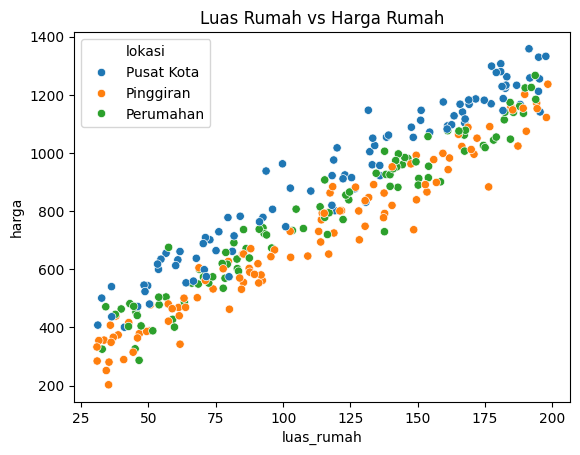

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n = 300

luas_rumah = np.random.uniform(30, 200, n)
jumlah_kamar = np.random.randint(1, 6, n)
lokasi = np.random.choice(['Pusat Kota', 'Pinggiran', 'Perumahan'], n)

harga = (
    100 +
    5 * luas_rumah +
    20 * jumlah_kamar +
    np.where(lokasi == 'Pusat Kota', 150, 0) +
    np.where(lokasi == 'Perumahan', 50, 0) +
    np.random.normal(0, 50, n)
)

df = pd.DataFrame({
    'luas_rumah': luas_rumah,
    'jumlah_kamar': jumlah_kamar,
    'lokasi': lokasi,
    'harga': harga
})

print("Shape:", df.shape)
print(df.describe().round(2))

sns.scatterplot(
    data=df,
    x='luas_rumah',
    y='harga',
    hue='lokasi'
)

plt.title("Luas Rumah vs Harga Rumah")
plt.show()

Pada langkah ini, dataset sintetis dibuat yang berisi informasi tentang luas, jumlah kamar, lokasi, dan harga rumah. Hasil eksplorasi awal menunjukkan karakteristik data yang akan digunakan dalam proses pemodelan. Selain itu, visualisasi scatter plot digunakan untuk menunjukkan hubungan antara luas dan harga rumah.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.get_dummies(
    df,
    columns=['lokasi'],
    drop_first=True,
    dtype=int
)

print("Kolom setelah encoding:")
print(df.columns.tolist())

X = df.drop('harga', axis=1)
y = df['harga']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Train: {X_train.shape[0]} baris")
print(f"Test : {X_test.shape[0]} baris")

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Kolom setelah encoding:
['luas_rumah', 'jumlah_kamar', 'harga', 'lokasi_Pinggiran', 'lokasi_Pusat Kota']
Train: 240 baris
Test : 60 baris


Proses preprocessing terdiri dari pembagian data menjadi data pelatihan dan pengujian, pengkodean data kategorik menggunakan One-Hot Encoding, dan pengukuran fitur pada variabel numerik. Tujuan dari proses ini adalah agar data siap untuk digunakan oleh algoritma pembelajaran mesin.

In [3]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_s, y_train)

print(f"Intercept: {model.intercept_:.3f}")

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_.round(3)
})

print(coef_df.sort_values(
    by='Koefisien',
    ascending=False
))

Intercept: 801.718
               Fitur  Koefisien
0         luas_rumah    256.561
3  lokasi_Pusat Kota     43.831
1       jumlah_kamar     23.308
2   lokasi_Pinggiran    -24.197


Data pelatihan menunjukkan model regresi linear berhasil dilatih. Koefisien menunjukkan seberapa besar pengaruh masing-masing fitur terhadap harga rumah. Fitur dengan koefisien positif yang lebih tinggi memiliki dampak yang lebih besar pada peningkatan harga rumah.

In [4]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_pred = model.predict(X_test_s)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== Evaluasi Model ===")
print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R²   = {r2:.3f}")

=== Evaluasi Model ===
MAE  = 41.29
RMSE = 52.07
R²   = 0.960


Nilai MAE dan RMSE menunjukkan tingkat kesalahan prediksi model, dan nilai R2 menunjukkan seberapa baik model mampu menjelaskan variasi data harga rumah. Semakin kecil nilai kesalahan dan semakin besar nilai R2, semakin baik performa model.

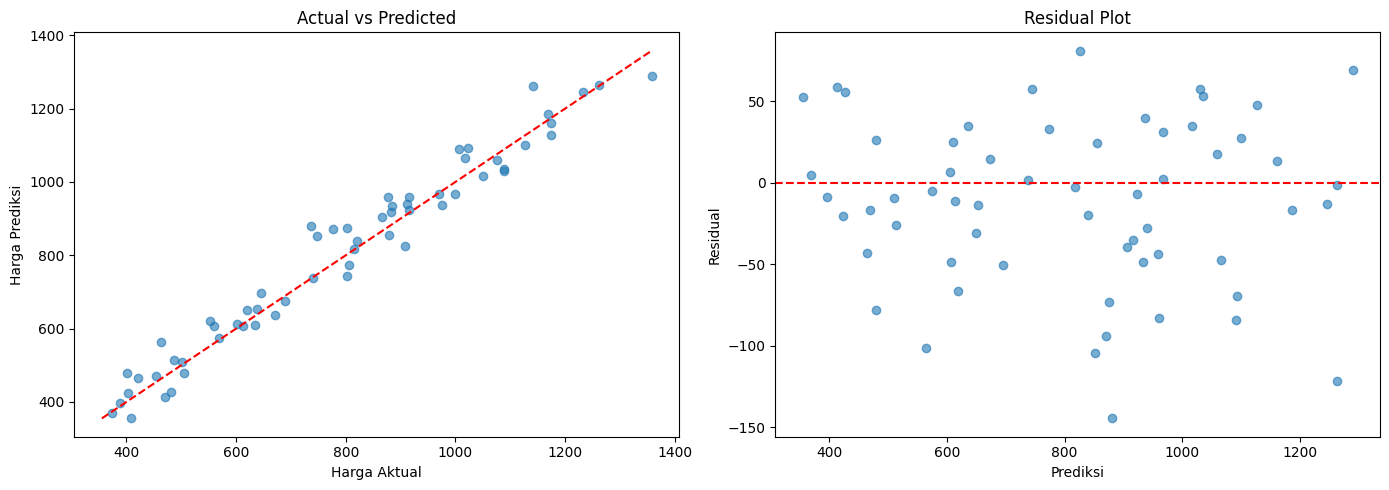

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Actual vs Predicted
axes[0].scatter(
    y_test,
    y_pred,
    alpha=0.6
)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

axes[0].plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--'
)

axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Harga Aktual")
axes[0].set_ylabel("Harga Prediksi")

# Residual Plot
residuals = y_test - y_pred

axes[1].scatter(
    y_pred,
    residuals,
    alpha=0.6
)

axes[1].axhline(
    y=0,
    color='red',
    linestyle='--'
)

axes[1].set_title("Residual Plot")
axes[1].set_xlabel("Prediksi")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

Visualisasi Actual vs. Predicted menunjukkan seberapa sesuai hasil prediksi model dengan nilai aktual. Pola kesalahan prediksi diamati dengan menggunakan rencana plot. Jika titik residual tersebar secara acak di sekitar garis nol, maka model regresi dianggap efektif dan memenuhi asumsi dasar regresi linear.


Kesimpulan: Praktikum ini mempelajari semua langkah-langkah yang diperlukan untuk membangun model regresi linear, mulai dari membuat dataset, melakukan preprocessing data, memberikan pelatihan kepada model, melakukan evaluasi performa, dan akhirnya menginterpretasikan hasil visualisasi. Hasil analisis menunjukkan bahwa faktor-faktor seperti luas, jumlah kamar, dan lokasi rumah memengaruhi harga rumah. Model yang dibangun mampu memprediksi harga rumah dengan cukup baik dengan mempertimbangkan fitur-fitur yang tersedia.